# 02 - Interpretability SHAP and Sensitivity
Interpretabilidad de modelos de retornos y clasificacion con SHAP, analisis de crisis 2022 y sensibilidad economica.

In [ ]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

base_dir = Path.cwd()
for root in [base_dir, *base_dir.parents]:
    if (root / "src").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        break

from src.data_processing.build_dataset import get_training_features

warnings.filterwarnings("ignore")
shap.initjs()

dataset_path = None
for root in [base_dir, *base_dir.parents]:
    candidate = root / "data" / "processed" / "dataset_entrenamiento_final.csv"
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError("dataset_entrenamiento_final.csv not found under data/processed")

df = pd.read_csv(dataset_path, parse_dates=["date"])
print("dataset:", dataset_path.resolve())
print("shape:", df.shape)

blacklist = [
    "precio_provincial_lag_1",
    "precio_provincial_lag_2",
    "precio_provincial_lag_3",
    "precio_vecinos_media_lag1",
    "precio_nacional_base_ma3",
    "precio_nacional_base_ma6",
    "precio_nacional_base_vol3",
    "precio_nacional_base_vol6"
]
target_candidates = ["precio_provincial_TARGET_H1", "precio_provincial_TARGET_H2", "precio_provincial_TARGET_H3"]
missing_targets = [t for t in target_candidates if t not in df.columns]
if missing_targets:
    raise ValueError(f"Missing target columns: {missing_targets}")
available_targets = target_candidates
horizons = [1, 3]

split_date = pd.Timestamp("2021-01-01")
train_mask = df["date"] < split_date
test_mask = ~train_mask

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()
print("train rows:", train_df.shape[0], "test rows:", test_df.shape[0])

identifiers = ["date", "provincia", "cereal_predominante"]
training_cols = get_training_features(df)
feature_cols = [
    c for c in training_cols
    if c in df.columns and c not in identifiers + available_targets
]
feature_cols = [c for c in feature_cols if c not in blacklist]

X_full = df[feature_cols].copy()
bool_cols = X_full.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X_full[bool_cols] = X_full[bool_cols].astype(int)

cat_cols = X_full.select_dtypes(include=["object", "category"]).columns.tolist()
if cat_cols:
    X_full = pd.get_dummies(X_full, columns=cat_cols, drop_first=False)

X_train = X_full.loc[train_mask].copy()
X_test = X_full.loc[test_mask].copy()
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

base_price_col = "precio_provincial_lag_1"
if base_price_col not in df.columns:
    raise ValueError("precio_provincial_lag_1 missing for targets")

def build_targets(horizon: int):
    target_reg = f"precio_provincial_TARGET_H{horizon}"
    y_train_reg = train_df[target_reg]
    y_test_reg = test_df[target_reg]
    base_train = train_df[base_price_col]
    base_test = test_df[base_price_col]
    y_train_clf = (y_train_reg - base_train > 0).astype(int)
    y_test_clf = (y_test_reg - base_test > 0).astype(int)
    return y_train_reg, y_test_reg, y_train_clf, y_test_clf, base_train, base_test

c:\Users\marco\Desktop\Repos\DATAGIA-21\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dataset: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\processed\dataset_entrenamiento_final.csv
shape: (7047, 78)
train rows: 5394 test rows: 1653


## 1. Entrenamiento de modelos (H1 y H3)
Regresion de retornos y clasificacion calibrada para interpretabilidad.

In [2]:
tscv = TimeSeriesSplit(n_splits=5)

reg_models = {
    "RF": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "XGB": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror")),
    ]),
}

clf_models = {
    "RF": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ]),
    "XGB": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(random_state=42, n_jobs=-1, eval_metric="logloss")),
    ]),
}

return_models = {}
clf_calibrated = {}

for h in horizons:
    y_train_reg, y_test_reg, y_train_clf, y_test_clf, base_train, base_test = build_targets(h)
    train_mask_h = base_train.notna() & (base_train != 0) & y_train_reg.notna()
    test_mask_h = base_test.notna() & (base_test != 0) & y_test_reg.notna()
    X_train_h = X_train.loc[train_mask_h]
    X_test_h = X_test.loc[test_mask_h]
    base_train_h = base_train.loc[train_mask_h]
    base_test_h = base_test.loc[test_mask_h]

    y_train_ret = (y_train_reg.loc[train_mask_h] - base_train_h) / base_train_h
    y_test_ret = (y_test_reg.loc[test_mask_h] - base_test_h) / base_test_h

    reg_model = reg_models["RF"]
    reg_model.fit(X_train_h, y_train_ret)
    return_models[h] = {
        "model": reg_model,
        "X_test": X_test_h,
        "y_test_ret": y_test_ret,
    }

    train_mask_c = y_train_clf.notna()
    test_mask_c = y_test_clf.notna()
    X_train_c = X_train.loc[train_mask_c]
    X_test_c = X_test.loc[test_mask_c]
    y_train_c = y_train_clf.loc[train_mask_c]
    y_test_c = y_test_clf.loc[test_mask_c]

    clf_model = clf_models["RF"]
    clf_model.fit(X_train_c, y_train_c)
    calib = CalibratedClassifierCV(estimator=clf_model, method="sigmoid", cv=TimeSeriesSplit(n_splits=3))
    calib.fit(X_train_c, y_train_c)
    proba_cal = calib.predict_proba(X_test_c)[:, 1]

    clf_calibrated[h] = {
        "model": calib,
        "X_test": X_test_c,
        "y_test": y_test_c,
        "proba": pd.Series(proba_cal, index=y_test_c.index),
    }

print("Models ready for SHAP: H1 and H3")

Models ready for SHAP: H1 and H3


## 2. SHAP summary (importancia global)
Resumen de contribuciones para retornos y clasificacion (H1, H3).

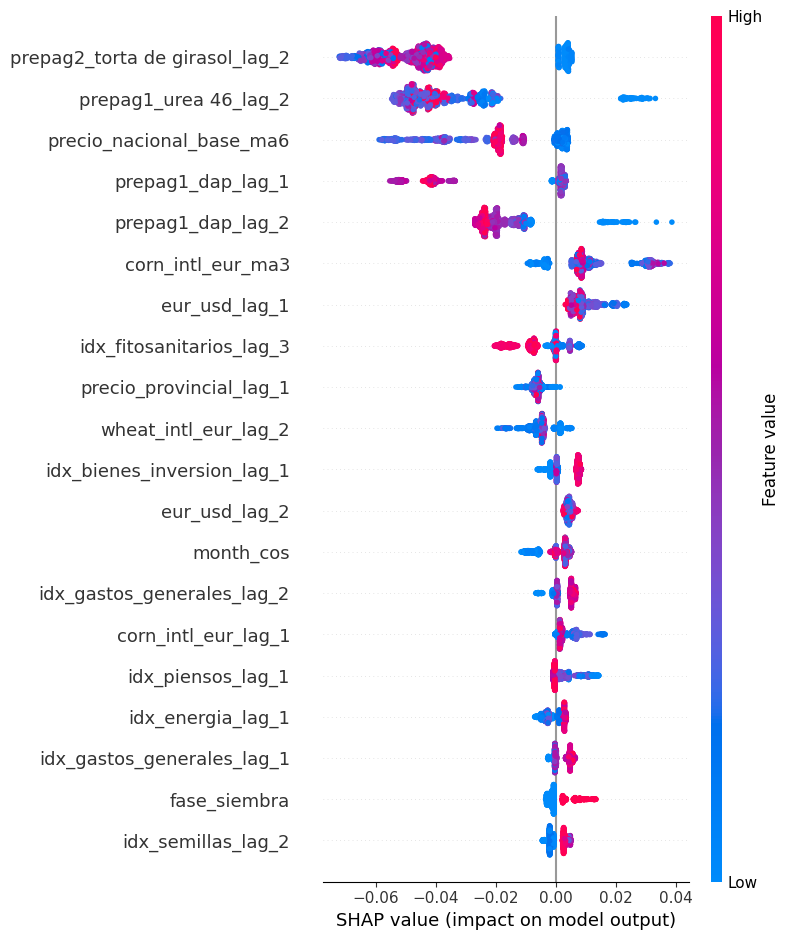

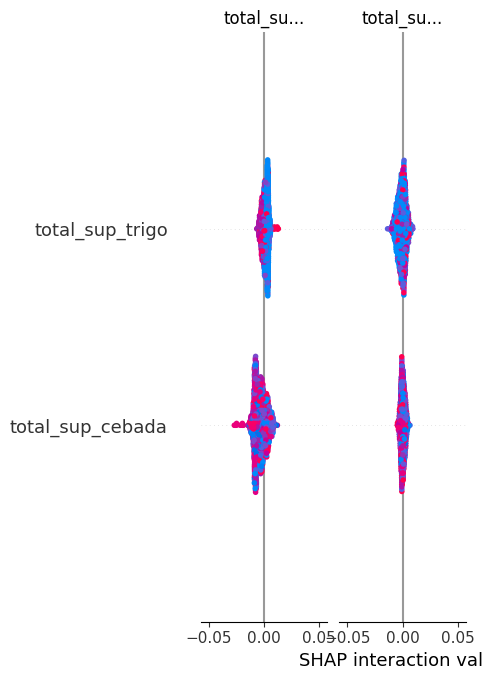

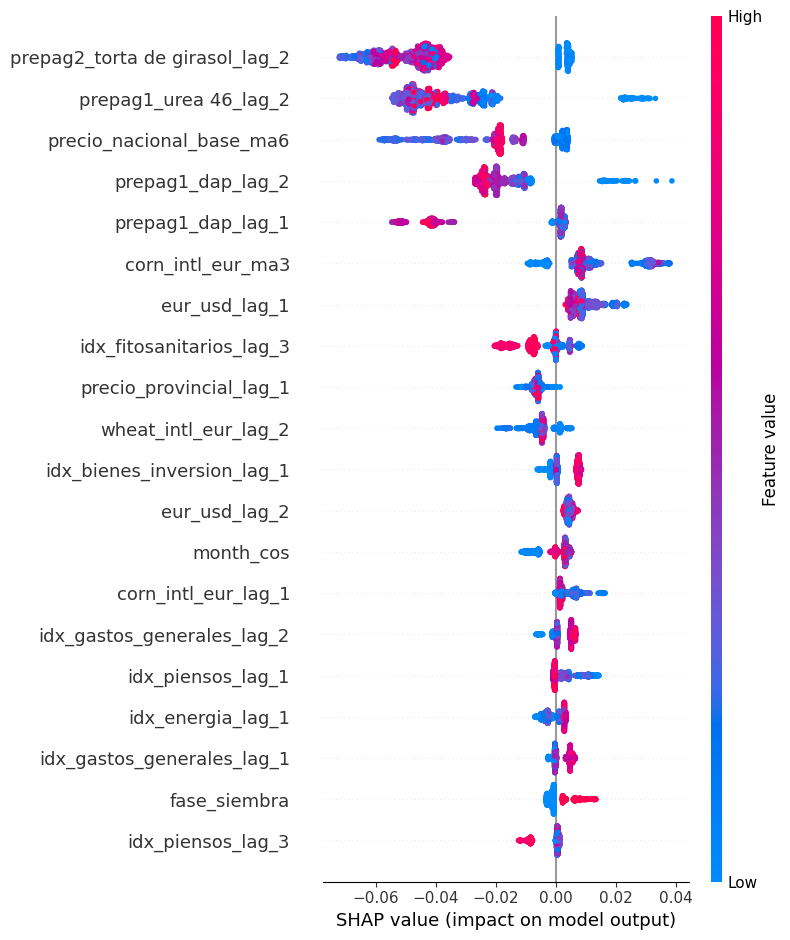

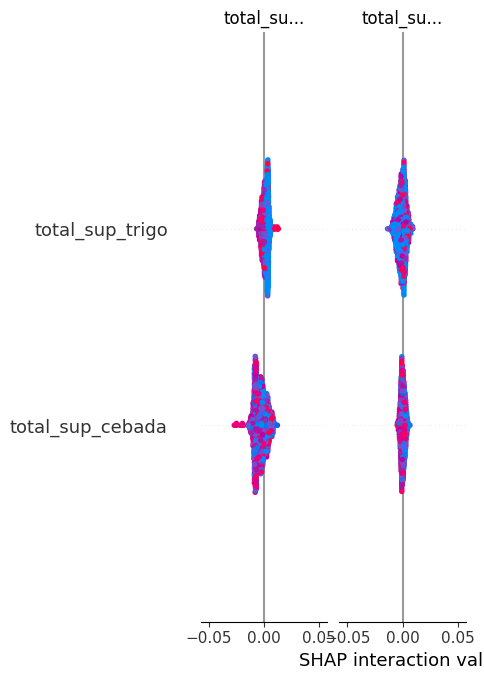

In [3]:
for h in horizons:
    ret = return_models[h]
    X_test_h = ret["X_test"]
    model = ret["model"].named_steps["model"]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_h, check_additivity=False)
    shap.summary_plot(shap_values, X_test_h, show=True, plot_type="dot")
    plt.show()

    clf = clf_calibrated[h]
    clf_model = clf["model"].estimator.named_steps["model"]
    clf_explainer = shap.TreeExplainer(clf_model)
    shap_values_clf = clf_explainer.shap_values(clf["X_test"], check_additivity=False)
    shap.summary_plot(shap_values_clf, clf["X_test"], show=True, plot_type="dot")
    plt.show()

## 3. Crisis marzo-abril 2022
SHAP decision plots para casos de alto error en provincias especificas.

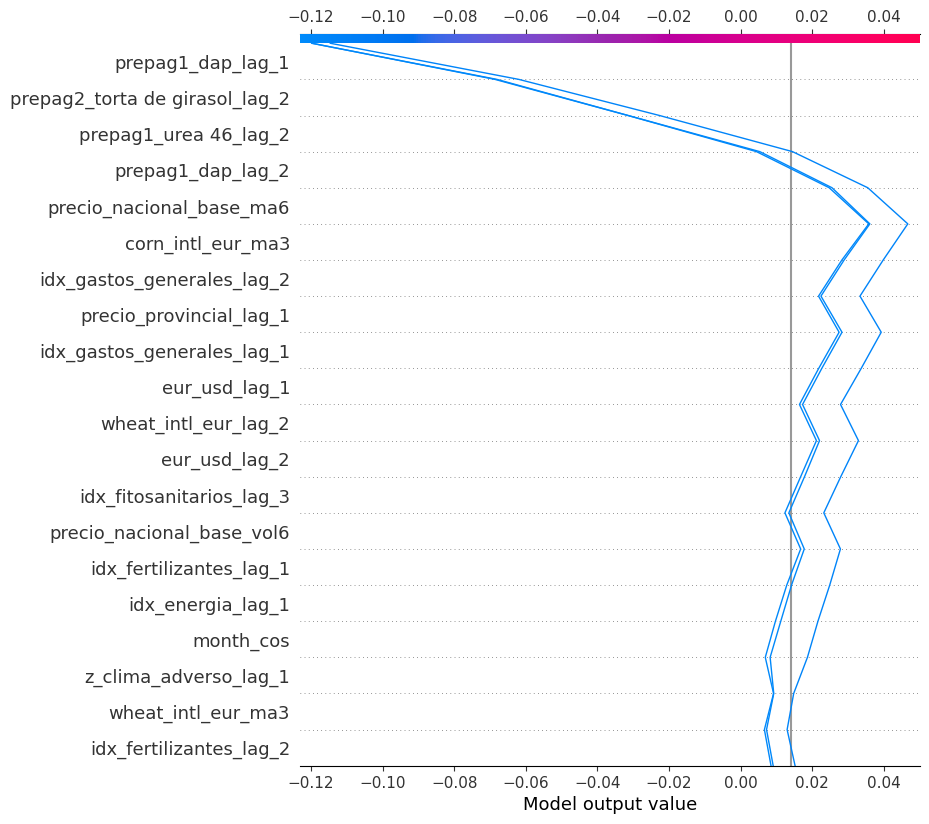

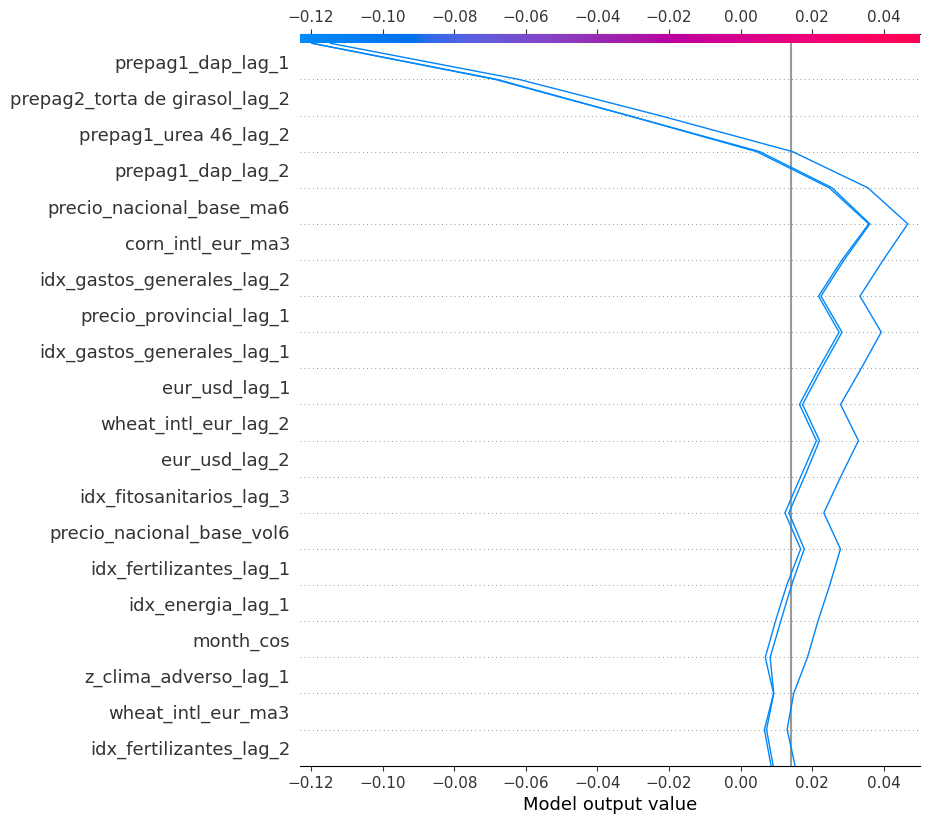

In [4]:
high_error_provinces = ["Lleida", "Cuenca"]
crisis_mask = (test_df["date"] >= pd.Timestamp("2022-03-01")) & (test_df["date"] <= pd.Timestamp("2022-04-30"))

for h in horizons:
    ret = return_models[h]
    X_test_h = ret["X_test"]
    y_test_ret = ret["y_test_ret"]
    preds = pd.Series(ret["model"].predict(X_test_h), index=y_test_ret.index)
    err = (y_test_ret - preds).abs()
    crisis_idx = X_test_h.index.intersection(test_df.loc[crisis_mask].index)
    crisis_err = err.loc[crisis_idx]
    crisis_df = pd.DataFrame({
        "provincia": test_df.loc[crisis_idx, "provincia"],
        "abs_err": crisis_err,
    })
    crisis_df = crisis_df[crisis_df["provincia"].isin(high_error_provinces)]
    top_idx = crisis_df.sort_values("abs_err", ascending=False).head(3).index

    if len(top_idx) == 0:
        continue

    model = ret["model"].named_steps["model"]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_h.loc[top_idx], check_additivity=False)
    shap.decision_plot(explainer.expected_value, shap_values, X_test_h.loc[top_idx], show=True)
    plt.show()

## 4. Sensibilidad what-if
Variacion del retorno al aumentar Urea 20%.

In [5]:
def pick_feature(df_in, candidates):
    for name in candidates:
        if name in df_in.columns:
            return name
    return None

wheat_col = pick_feature(X_test, ["wheat_intl_eur_ma3", "wheat_intl_eur_lag_1", "wheat_intl_eur"])
urea_col = pick_feature(X_test, ["prepag1_urea 46_lag_1", "prepag1_urea_46_lag_1", "prepag1_urea 46"])

for h in horizons:
    ret = return_models[h]
    X_test_h = ret["X_test"]
    model = ret["model"]
    base_row = X_test_h.iloc[[0]].copy()
    if urea_col and urea_col in base_row.columns:
        base_pred = model.predict(base_row)[0]
        base_row[urea_col] = base_row[urea_col] * 1.2
        pert_pred = model.predict(base_row)[0]
        print(f"H{h} sensibilidad Urea +20%: delta retorno = {pert_pred - base_pred:.6f}")
    else:
        print(f"H{h} sensibilidad Urea +20%: columna no encontrada")

H1 sensibilidad Urea +20%: delta retorno = 0.000089
H3 sensibilidad Urea +20%: delta retorno = 0.000089


## 5. Interacciones espaciales
SHAP dependence plots con latitud/distancia al puerto vs precio internacional.

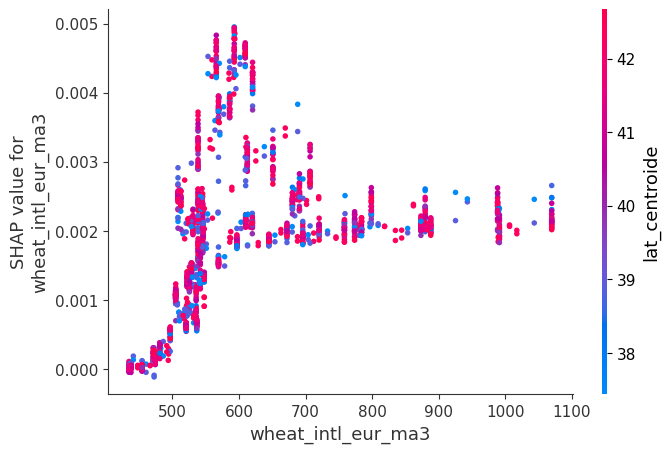

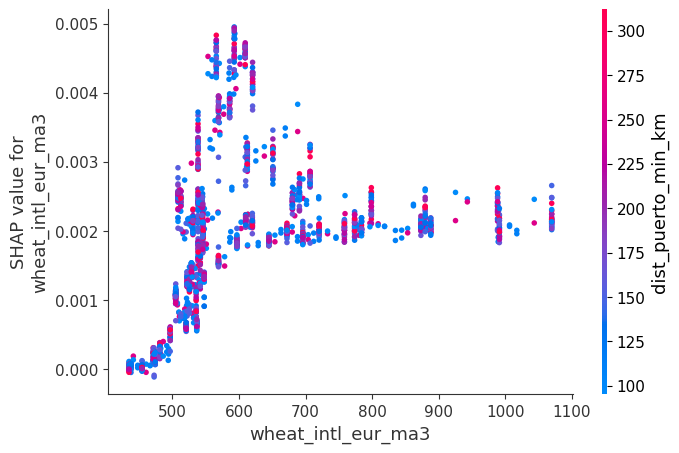

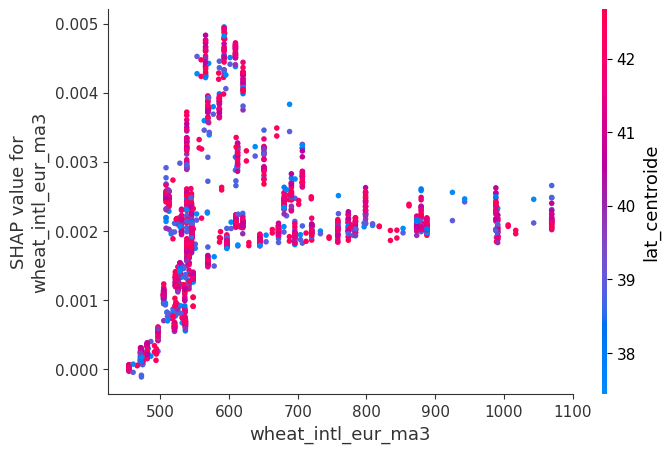

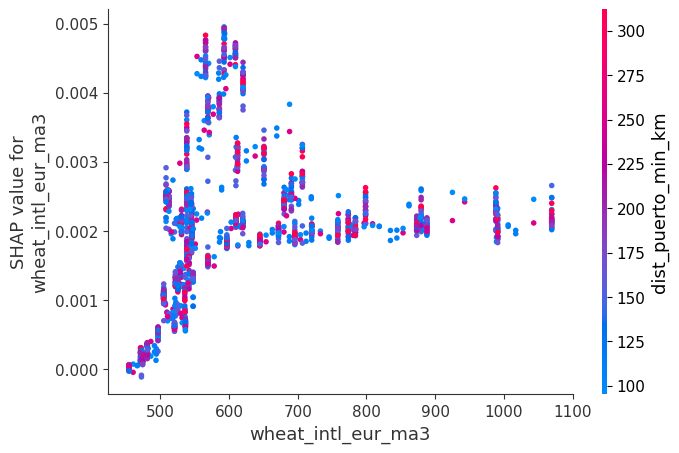

In [6]:
lat_col = pick_feature(X_test, ["lat_centroide", "lat"])
port_col = pick_feature(X_test, ["dist_puerto_min_km", "dist_puerto"])

for h in horizons:
    ret = return_models[h]
    X_test_h = ret["X_test"]
    model = ret["model"].named_steps["model"]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_h, check_additivity=False)

    if wheat_col:
        if lat_col:
            shap.dependence_plot(wheat_col, shap_values, X_test_h, interaction_index=lat_col, show=True)
            plt.show()
        if port_col:
            shap.dependence_plot(wheat_col, shap_values, X_test_h, interaction_index=port_col, show=True)
            plt.show()

## 6. Reporte
Genera INTERPRETABILIDAD_Y_SENSIBILIDAD_V1.md en reports/.

In [7]:
report_root = None
for root in [base_dir, *base_dir.parents]:
    candidate = root / "reports"
    if candidate.exists():
        report_root = candidate
        break
if report_root is None:
    report_root = base_dir / "reports"
    report_root.mkdir(parents=True, exist_ok=True)

report_path = report_root / "INTERPRETABILIDAD_Y_SENSIBILIDAD_V1.md"

lines = [
    "# INTERPRETABILIDAD_Y_SENSIBILIDAD_V1",
    "",
    "## Resumen",
    "Analisis SHAP global, crisis 2022 y sensibilidad economica.",
    "",
    "## Hallazgos clave",
    "- Revisar si Urea/Trigo explican shocks de 2022 en H1 y H3.",
    "- Validar que el signo de SHAP sea economico (Urea al alza no debe bajar cereal).",
    "- Verificar interaccion con latitud/distancia a puerto.",
    "",
    "## Observaciones de crisis (marzo-abril 2022)",
    "Ver decision plots en el notebook para casos de alto error.",
    "",
    "## Sensibilidad Urea +20%",
    "Ver salida de la celda de sensibilidad para cada horizonte.",
    "",
    "## Interacciones espaciales",
    "Consultar dependence plots (trigo vs latitud/distancia a puerto).",
    "",
]

report_path.write_text("\n".join(lines), encoding="utf-8")
print("Reporte guardado en:", report_path.resolve())

Reporte guardado en: C:\Users\marco\Desktop\Repos\DATAGIA-21\reports\INTERPRETABILIDAD_Y_SENSIBILIDAD_V1.md
